In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import re
from collections import Counter

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

In [2]:
train_df = pd.read_csv("data/train.csv", header=None)
test_df = pd.read_csv("data/test.csv", header=None)

train_df.columns = ["label","title","text"]
test_df.columns = ["label","title","text"]

# convert labels to integer
train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)

# combine title and description
train_df["text"] = train_df["title"] + " " + train_df["text"]
test_df["text"] = test_df["title"] + " " + test_df["text"]

# ---------- Tokenization ----------
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]","",text)
    return text.split()

In [3]:
counter = Counter()

for t in train_df["text"]:
    counter.update(tokenize(t))

VOCAB_SIZE = 30000

vocab = {w:i+2 for i,(w,_) in enumerate(counter.most_common(VOCAB_SIZE))}
vocab["<pad>"] = 0
vocab["<unk>"] = 1

In [4]:
MAX_LEN = 50

def encode(text):

    tokens = tokenize(text)
    ids = [vocab.get(t,1) for t in tokens]

    if len(ids) < MAX_LEN:
        ids += [0]*(MAX_LEN-len(ids))
    else:
        ids = ids[:MAX_LEN]

    return torch.tensor(ids)

In [5]:
class NewsDataset(Dataset):

    def __init__(self, df):

        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        x = encode(self.texts[idx])
        y = self.labels[idx] - 1

        return x, y

In [6]:
train_loader = DataLoader(
    NewsDataset(train_df),
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    NewsDataset(test_df),
    batch_size=64
)

In [7]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size,100)

        self.lstm = nn.LSTM(
            input_size=100,
            hidden_size=128,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(128,4)

    def forward(self,x):

        x = self.embedding(x)

        out,(h,c) = self.lstm(x)

        out = self.dropout(h[-1])

        return self.fc(out)

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMClassifier(len(vocab)).to(device)
writer = SummaryWriter("runs/news_lstm")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [9]:
train_losses = []

for epoch in range(10):

    model.train()
    total_loss = 0

    for x,y in train_loader:

        x,y = x.to(device),y.to(device)

        optimizer.zero_grad()

        out = model(x)

        loss = criterion(out,y)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(),5)

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss/len(train_loader)
    train_losses.append(avg_loss)
    writer.add_scalar("Loss/train", avg_loss, epoch)

    print("Epoch:",epoch+1,"Loss:",avg_loss)

Epoch: 1 Loss: 0.8646743093887965
Epoch: 2 Loss: 0.3200451262096564
Epoch: 3 Loss: 0.24094633700648943
Epoch: 4 Loss: 0.19368490597705046
Epoch: 5 Loss: 0.15642834989925225
Epoch: 6 Loss: 0.12466611313819885
Epoch: 7 Loss: 0.0970685098896424
Epoch: 8 Loss: 0.07689763983438412
Epoch: 9 Loss: 0.06195617234793802
Epoch: 10 Loss: 0.04752852975788216


In [10]:
model.eval()

preds=[]
labels=[]

with torch.no_grad():

    for x,y in test_loader:

        x = x.to(device)

        out = model(x)

        p = torch.argmax(out,dim=1).cpu().numpy()

        preds.extend(p)
        labels.extend(y.numpy())

Accuracy: 0.9053947368421053
Precision: 0.9059490995562464
Recall: 0.9053947368421053
F1 Score: 0.905286754548077
Confusion Matrix:
 [[1727   44   85   44]
 [  22 1845   22   11]
 [  58   23 1698  121]
 [  69   22  198 1611]]


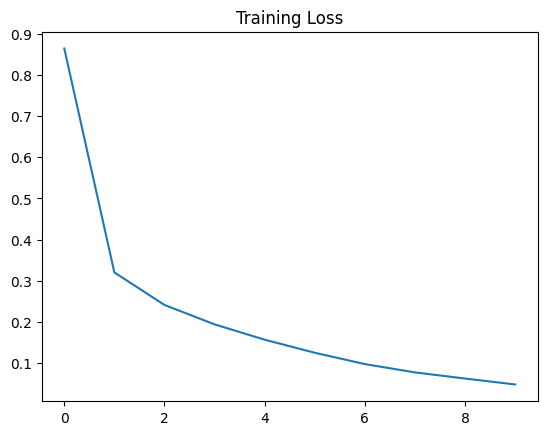

In [11]:
acc = accuracy_score(labels,preds)

precision,recall,f1,_ = precision_recall_fscore_support(
    labels,preds,
    average='weighted'
)

cm = confusion_matrix(labels,preds)


writer.add_scalar("Metrics/accuracy", acc, 0)
writer.add_scalar("Metrics/precision", precision, 0)
writer.add_scalar("Metrics/recall", recall, 0)
writer.add_scalar("Metrics/f1", f1, 0)
writer.close()

print("Accuracy:",acc)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("Confusion Matrix:\n",cm)


# ---------- Loss Curve ----------
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()